# OULAD Individual Project Notebook

This notebook is designed to be opened directly in the Jupyter Notebook app. It rebuilds the week-4 OULAD feature table, trains the two modelling pipelines, and displays the final tables and figures inside the notebook cells.

The six original OULAD source files are still required as raw inputs: `studentInfo.csv`, `studentRegistration.csv`, `studentVle.csv`, `vle.csv`, `assessments.csv`, and `studentAssessment.csv`. The generated summary CSV files under `artifacts/` are no longer needed to read the notebook results.


## 1. Setup

Run this cell first. It imports the project code, configures table display, and confirms that the notebook is running from the project folder.


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from submission_outputs import build_submission_outputs

project_root = Path.cwd()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.4f}".format)

display(Markdown(f"Project folder: `{project_root}`"))


Project folder: `C:\Users\giftv\Documents\4th IE and shared year courses\ELEN4025\Pipeline 2`

## 2. Run the Analysis

This cell rebuilds the feature table if needed, refits the models, creates the figures, and keeps the final tables in memory as DataFrames.


In [2]:
notebook_outputs = build_submission_outputs(
    project_root,
    force_rebuild=False,
    save_tables=False,
)

results = notebook_outputs["results"]
feature_table = notebook_outputs["feature_table"]
tables = notebook_outputs["table_data"]
figures = notebook_outputs["figures"]

display(Markdown("Analysis complete. The tables below are displayed from in-memory DataFrames, not from generated CSV files."))
display(
    pd.DataFrame(
        [
            {"Item": "Feature table rows", "Value": len(feature_table)},
            {"Item": "Feature columns", "Value": len(results["feature_columns"])},
            {"Item": "Training rows", "Value": results["train_size"]},
            {"Item": "Validation rows", "Value": results["validation_size"]},
            {"Item": "Test rows", "Value": results["test_size"]},
            {"Item": "Best logistic threshold", "Value": results["logistic_best_threshold"]},
            {"Item": "Best calibrated CatBoost threshold", "Value": results["calibrated_best_threshold"]},
        ]
    )
)


Analysis complete. The tables below are displayed from in-memory DataFrames, not from generated CSV files.

,Item,Value
0,Feature table rows,32593.0000
1,Feature columns,38.0000
2,Training rows,19555.0000
3,Validation rows,6519.0000
4,Test rows,6519.0000
5,Best logistic threshold,0.3000
6,Best calibrated CatBoost threshold,0.3000


## 3. Data Checks

These tables document the raw-data counts, derived subsets, class balance, and missing-value fields used in the pipeline.


In [3]:
display(Markdown("### Row Counts"))
display(tables["row_counts"])

display(Markdown("### Class Balance"))
display(tables["class_balance"])

display(Markdown("### Missing Values"))
display(tables["missing_summary"])


### Row Counts

,Table or derived subset,Rows
0,studentInfo.csv,32593
1,studentRegistration.csv,32593
2,vle.csv,6364
3,studentVle.csv,10655280
4,studentVle rows within day 0-27,2112323
5,Exact duplicate studentVle rows removed before...,140592
6,assessments.csv,206
7,Assessments due by day 27,17
8,studentAssessment.csv,173912
9,Assessment submissions by day 27,20739


### Class Balance

,Binary target,Original OULAD values,Count,Percentage
0,Favourable,"Pass, Distinction",15385,47.2%
1,Unfavourable,"Fail, Withdrawn",17208,52.8%


### Missing Values

,Column,Missing count
0,days_since_last_activity_w4,4707
1,first_activity_day_w4,4707
2,imd_band,1111
3,date_registration,45


## 4. Feature Engineering

The model table is one row per student-module-presentation record. The preview confirms the engineered week-4 activity, registration, demographic, and early-assessment fields before modelling.


In [4]:
display(Markdown("### Feature Table Preview"))
display(feature_table.head(10))

display(Markdown("### Feature Catalog Preview"))
display(tables["feature_catalog"].head(25))


### Feature Table Preview

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,binary_target,target,date_registration,registered_before_start_days,late_registration_flag,total_clicks_w4,first_activity_day_w4,active_days_w4,unique_sites_w4,recommended_clicks_w4,forumng_clicks_w4,homepage_clicks_w4,other_activity_clicks_w4,oucontent_clicks_w4,page_clicks_w4,quiz_clicks_w4,resource_clicks_w4,subpage_clicks_w4,url_clicks_w4,clicks_per_active_day_w4,days_since_last_activity_w4,recommended_click_ratio_w4,early_assessment_due_count,weighted_due_by_w4,early_assessment_submitted_count,on_time_submission_count,late_submission_count,mean_submission_delay_days,weighted_submitted_by_w4,submitted_any_early_assessment
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,Favourable,1,-159.0000,159.0000,0,303,0,7.0000,24.0000,0.0000,53,35,0,195,0,0,9,10,1,43.2857,9.0000,0.0000,1.0000,10.0000,1.0000,1.0000,0.0000,-1.0000,10.0000,1.0000
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,Favourable,1,-53.0000,53.0000,0,329,0,11.0000,21.0000,0.0000,125,75,0,77,0,0,0,32,20,29.9091,3.0000,0.0000,1.0000,10.0000,1.0000,0.0000,1.0000,3.0000,10.0000,1.0000
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,Unfavourable,0,-92.0000,92.0000,0,159,4,6.0000,17.0000,0.0000,67,27,0,52,0,0,0,10,3,26.5000,15.0000,0.0000,1.0000,10.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,Favourable,1,-52.0000,52.0000,0,284,1,16.0000,21.0000,0.0000,77,64,0,97,0,0,1,31,14,17.7500,2.0000,0.0000,1.0000,10.0000,1.0000,1.0000,0.0000,-2.0000,10.0000,1.0000
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,Favourable,1,-176.0000,176.0000,0,267,1,16.0000,18.0000,0.0000,60,50,0,143,0,0,0,11,3,16.6875,1.0000,0.0000,1.0000,10.0000,1.0000,0.0000,1.0000,7.0000,10.0000,1.0000
5,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass,Favourable,1,-110.0000,110.0000,0,446,0,23.0000,20.0000,0.0000,215,119,0,86,0,0,0,16,10,19.3913,2.0000,0.0000,1.0000,10.0000,1.0000,1.0000,0.0000,0.0000,10.0000,1.0000
6,AAA,2013J,45462,M,Scotland,HE Qualification,30-40%,0-35,0,60,N,Pass,Favourable,1,-67.0000,67.0000,0,304,3,10.0000,20.0000,0.0000,19,56,2,194,0,0,0,27,6,30.4000,0.0000,0.0000,1.0000,10.0000,1.0000,0.0000,1.0000,1.0000,10.0000,1.0000
7,AAA,2013J,45642,F,North Western Region,A Level or Equivalent,90-100%,0-35,0,120,N,Pass,Favourable,1,-29.0000,29.0000,0,356,4,15.0000,23.0000,0.0000,120,72,1,110,0,0,1,36,16,23.7333,0.0000,0.0000,1.0000,10.0000,1.0000,1.0000,0.0000,-1.0000,10.0000,1.0000
8,AAA,2013J,52130,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,0,90,N,Pass,Favourable,1,-33.0000,33.0000,0,345,1,15.0000,26.0000,0.0000,73,83,2,120,0,0,2,45,20,23.0000,1.0000,0.0000,1.0000,10.0000,1.0000,1.0000,0.0000,0.0000,10.0000,1.0000
9,AAA,2013J,53025,M,North Region,Post Graduate Qualification,<NA>,55<=,0,60,N,Pass,Favourable,1,-179.0000,179.0000,0,376,2,14.0000,20.0000,0.0000,246,39,0,63,0,0,1,17,10,26.8571,0.0000,0.0000,1.0000,10.0000,1.0000,1.0000,0.0000,-10.0000,10.0000,1.0000


### Feature Catalog Preview

,Feature,Source CSV(s),Original column(s) used,Data type,Definition,How computed,Week availability (2/4/6/8),Missing count,Outliers count,Duplicate count,Leakage risk,Notes
0,code_module,studentInfo.csv,code_module,cat,Module identifier.,as-is,2/4/6/8,0,N/A,0,None,Static course identifier.
1,code_presentation,studentInfo.csv,code_presentation,cat,Presentation identifier.,as-is,2/4/6/8,0,N/A,0,None,Static presentation identifier.
2,gender,studentInfo.csv,gender,cat,Student gender category.,as-is,2/4/6/8,0,N/A,0,Low,Fairness-sensitive demographic field.
3,region,studentInfo.csv,region,cat,Student region category.,as-is,2/4/6/8,0,N/A,0,Low,Fairness-sensitive demographic field.
4,highest_education,studentInfo.csv,highest_education,cat,Highest education band.,as-is,2/4/6/8,0,N/A,0,Low,Static background feature.
5,imd_band,studentInfo.csv,imd_band,cat,Socioeconomic deprivation band.,as-is,2/4/6/8,1111,N/A,0,Low,Fairness-sensitive socioeconomic proxy.
6,age_band,studentInfo.csv,age_band,cat,Age category.,as-is,2/4/6/8,0,N/A,0,Low,Static demographic band.
7,num_of_prev_attempts,studentInfo.csv,num_of_prev_attempts,num,Number of prior attempts on the module.,as-is,2/4/6/8,0,4172,0,None,Static history feature.
8,studied_credits,studentInfo.csv,studied_credits,num,Number of studied credits.,as-is,2/4/6/8,0,350,0,None,Static workload feature.
9,disability,studentInfo.csv,disability,cat,Disability disclosure flag.,as-is,2/4/6/8,0,N/A,0,Low,Fairness-sensitive field.


## 5. Final Test-Set Model Comparison

This is the direct test-set output from the logistic-regression baseline and the CatBoost-based self-learned model.


In [5]:
metric_columns = [
    "model",
    "split",
    "threshold",
    "accuracy",
    "precision",
    "recall",
    "specificity",
    "fpr",
    "f1",
    "log_loss",
    "roc_auc",
]

display(results["comparison_table"][metric_columns])


,model,split,threshold,accuracy,precision,recall,specificity,fpr,f1,log_loss,roc_auc
0,Logistic Regression,test,0.5000,0.7374,0.7017,0.7715,0.7069,0.2931,0.7350,0.5092,0.8185
1,Logistic Regression (tuned threshold),test,0.3000,0.7084,0.6273,0.9415,0.5000,0.5000,0.7530,0.5092,0.8185
2,CatBoost,test,0.5000,0.7414,0.6963,0.8018,0.6874,0.3126,0.7453,0.4989,0.8264
3,Calibrated CatBoost (tuned threshold),test,0.3000,0.7294,0.6521,0.9145,0.5639,0.4361,0.7614,0.5044,0.8264


## 6. Submission Pipeline Comparison Table

This is the final report-style comparison table, generated directly in the notebook from the model outputs.


In [6]:
display(tables["pipeline_comparison"])


,Pipeline ID,Feature set,Encoding,Scaling,Model,Evaluation method,Hyperparameters,Seed,Chosen threshold,Accuracy,Precision,Recall,Specificity,FPR,F1,Log loss,AUC
0,P1,All week-4 features,Most-frequent imputation + one-hot categorical...,StandardScaler on numeric columns only,LogisticRegression(max_iter=1000),Split 60/20/20 with threshold selection on val...,"max_iter=1000, random_state=42",42,0.5000,0.7374,0.7017,0.7715,0.7069,0.2931,0.7350,0.5092,0.8185
1,P1-T,All week-4 features,Most-frequent imputation + one-hot categorical...,StandardScaler on numeric columns only,LogisticRegression(max_iter=1000),Split 60/20/20 with threshold selection on val...,"max_iter=1000, random_state=42",42,0.3000,0.7084,0.6273,0.9415,0.5000,0.5000,0.7530,0.5092,0.8185
2,P2,All week-4 features,Native categorical handling with explicit Miss...,None,CatBoostClassifier,Split 60/20/20 with threshold selection on val...,"loss_function=Logloss, eval_metric=AUC, depth=...",42,0.5000,0.7414,0.6963,0.8018,0.6874,0.3126,0.7453,0.4989,0.8264
3,P2-T,All week-4 features,Native categorical handling with explicit Miss...,None,Calibrated CatBoostClassifier (sigmoid),Split 60/20/20 with threshold selection on val...,"loss_function=Logloss, eval_metric=AUC, depth=...",42,0.3000,0.7294,0.6521,0.9145,0.5639,0.4361,0.7614,0.5044,0.8264


## 7. Validation Threshold Sweep

The validation sweep shows why the threshold-tuned rows use a lower intervention threshold than the default 0.5 rule.


In [7]:
threshold_view = (
    results["threshold_sweep"]
    .query("split == 'validation'")
    .sort_values(["model", "threshold"])
    .reset_index(drop=True)
)

display(threshold_view)


,model,split,threshold,accuracy,log_loss,precision,recall,specificity,fpr,f1,roc_auc,tn,fp,fn,tp
0,Calibrated CatBoost,validation,0.1000,0.6564,0.4921,0.5794,0.9922,0.3562,0.6438,0.7316,0.8358,1226,2216,24,3053
1,Calibrated CatBoost,validation,0.2000,0.7067,0.4921,0.6217,0.9672,0.4739,0.5261,0.7569,0.8358,1631,1811,101,2976
2,Calibrated CatBoost,validation,0.3000,0.7326,0.4921,0.6536,0.9223,0.5630,0.4370,0.7651,0.8358,1938,1504,239,2838
3,Calibrated CatBoost,validation,0.4000,0.7480,0.4921,0.6849,0.8632,0.6450,0.3550,0.7638,0.8358,2220,1222,421,2656
4,Calibrated CatBoost,validation,0.5000,0.7490,0.4921,0.7126,0.7849,0.7170,0.2830,0.7470,0.8358,2468,974,662,2415
5,Calibrated CatBoost,validation,0.6000,0.7382,0.4921,0.7480,0.6714,0.7978,0.2022,0.7077,0.8358,2746,696,1011,2066
6,Calibrated CatBoost,validation,0.7000,0.7081,0.4921,0.7965,0.5125,0.8829,0.1171,0.6237,0.8358,3039,403,1500,1577
7,Calibrated CatBoost,validation,0.8000,0.6343,0.4921,0.8496,0.2736,0.9567,0.0433,0.4140,0.8358,3293,149,2235,842
8,Calibrated CatBoost,validation,0.9000,0.5295,0.4921,0.9167,0.0036,0.9997,0.0003,0.0071,0.8358,3441,1,3066,11
9,Logistic Regression,validation,0.1000,0.6561,0.4956,0.5794,0.9896,0.3579,0.6421,0.7309,0.8274,1232,2210,32,3045


## 8. Five-Fold Cross-Validation Summary

Cross-validation is computed on the training portion only and summarises probability quality using ROC AUC and log loss.


In [8]:
display(Markdown("### Summary"))
display(tables["cv_summary"])

display(Markdown("### Fold-Level Scores"))
display(tables["cv_folds"])


### Summary

,model,roc_auc_mean,roc_auc_std,log_loss_mean,log_loss_std
0,CatBoost,0.8262,0.0049,0.4989,0.0056
1,Logistic Regression,0.8155,0.0045,0.5141,0.0047


### Fold-Level Scores

,model,fold,roc_auc,log_loss
0,Logistic Regression,1,0.8112,0.5173
1,CatBoost,1,0.8223,0.5037
2,Logistic Regression,2,0.8202,0.5074
3,CatBoost,2,0.8288,0.4963
4,Logistic Regression,3,0.8104,0.5189
5,CatBoost,3,0.8214,0.5044
6,Logistic Regression,4,0.8191,0.5156
7,CatBoost,4,0.8332,0.4907
8,Logistic Regression,5,0.8165,0.5113
9,CatBoost,5,0.8253,0.4993


## 9. Figures

The figures are displayed in the notebook output. After running all cells and saving the notebook, Jupyter stores these visible outputs inside the `.ipynb` file.


### Figure 1: Methodology block diagram

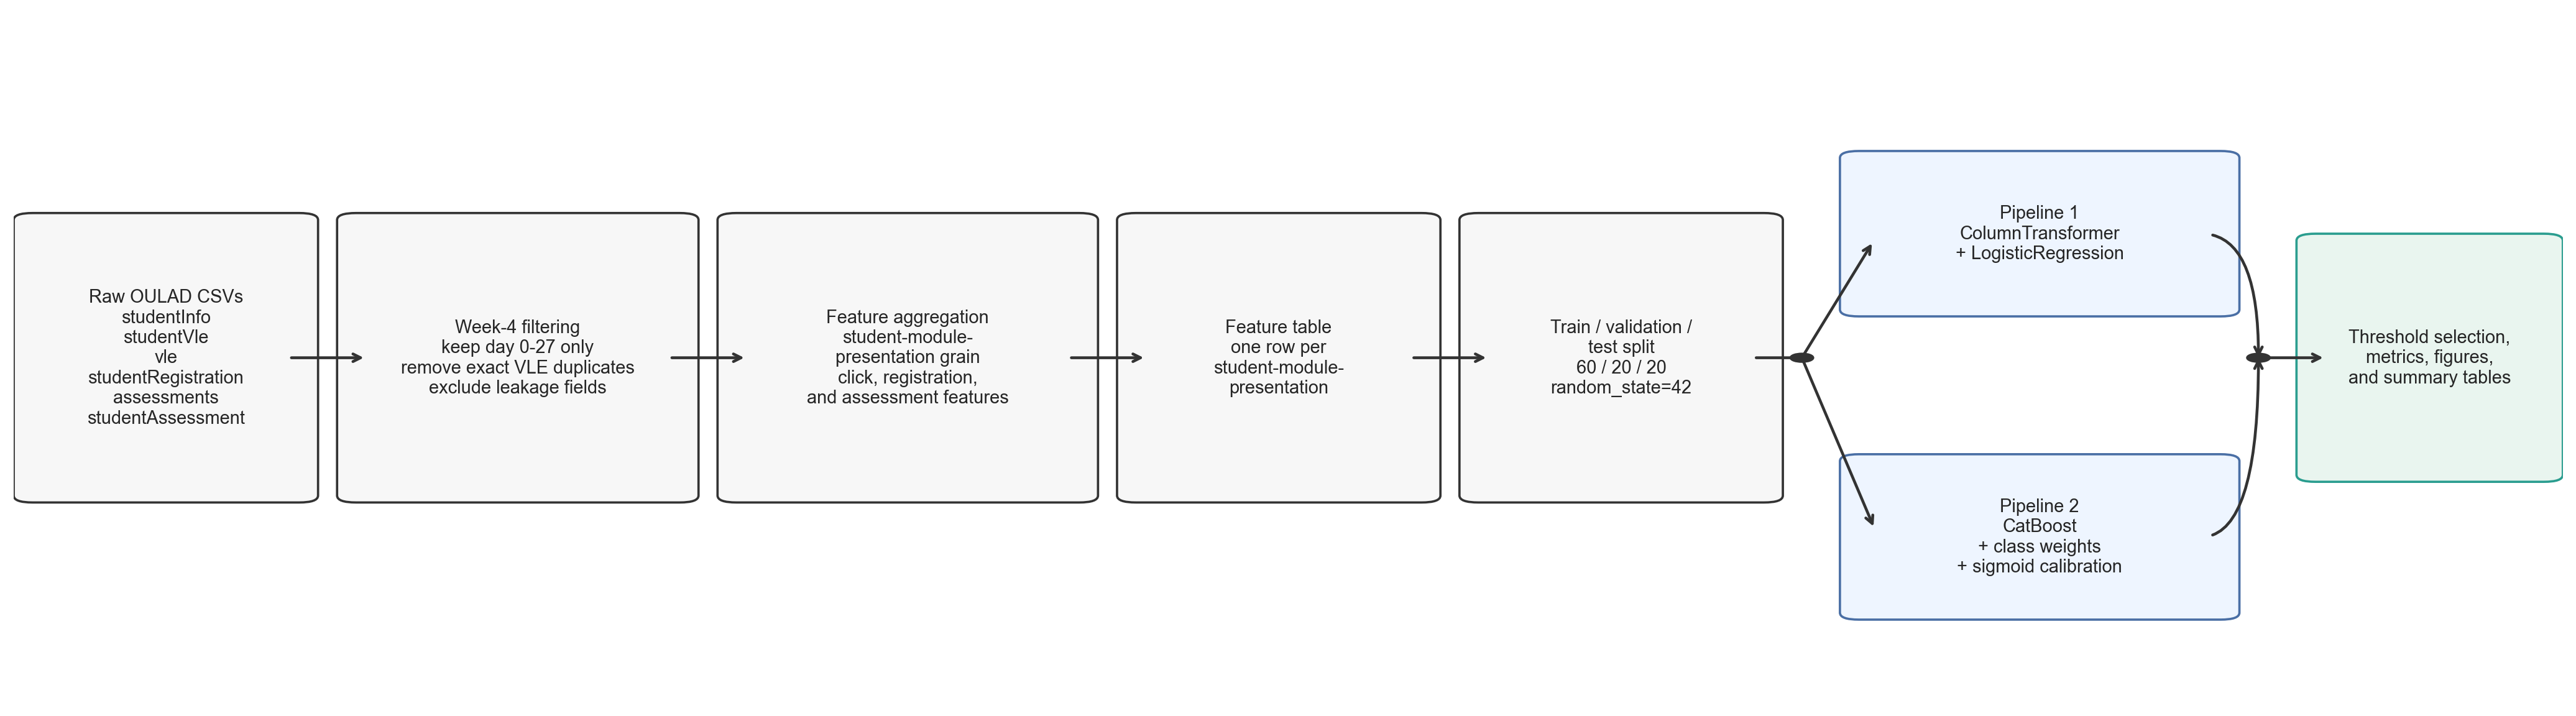

### Figure 2: Total clicks by outcome

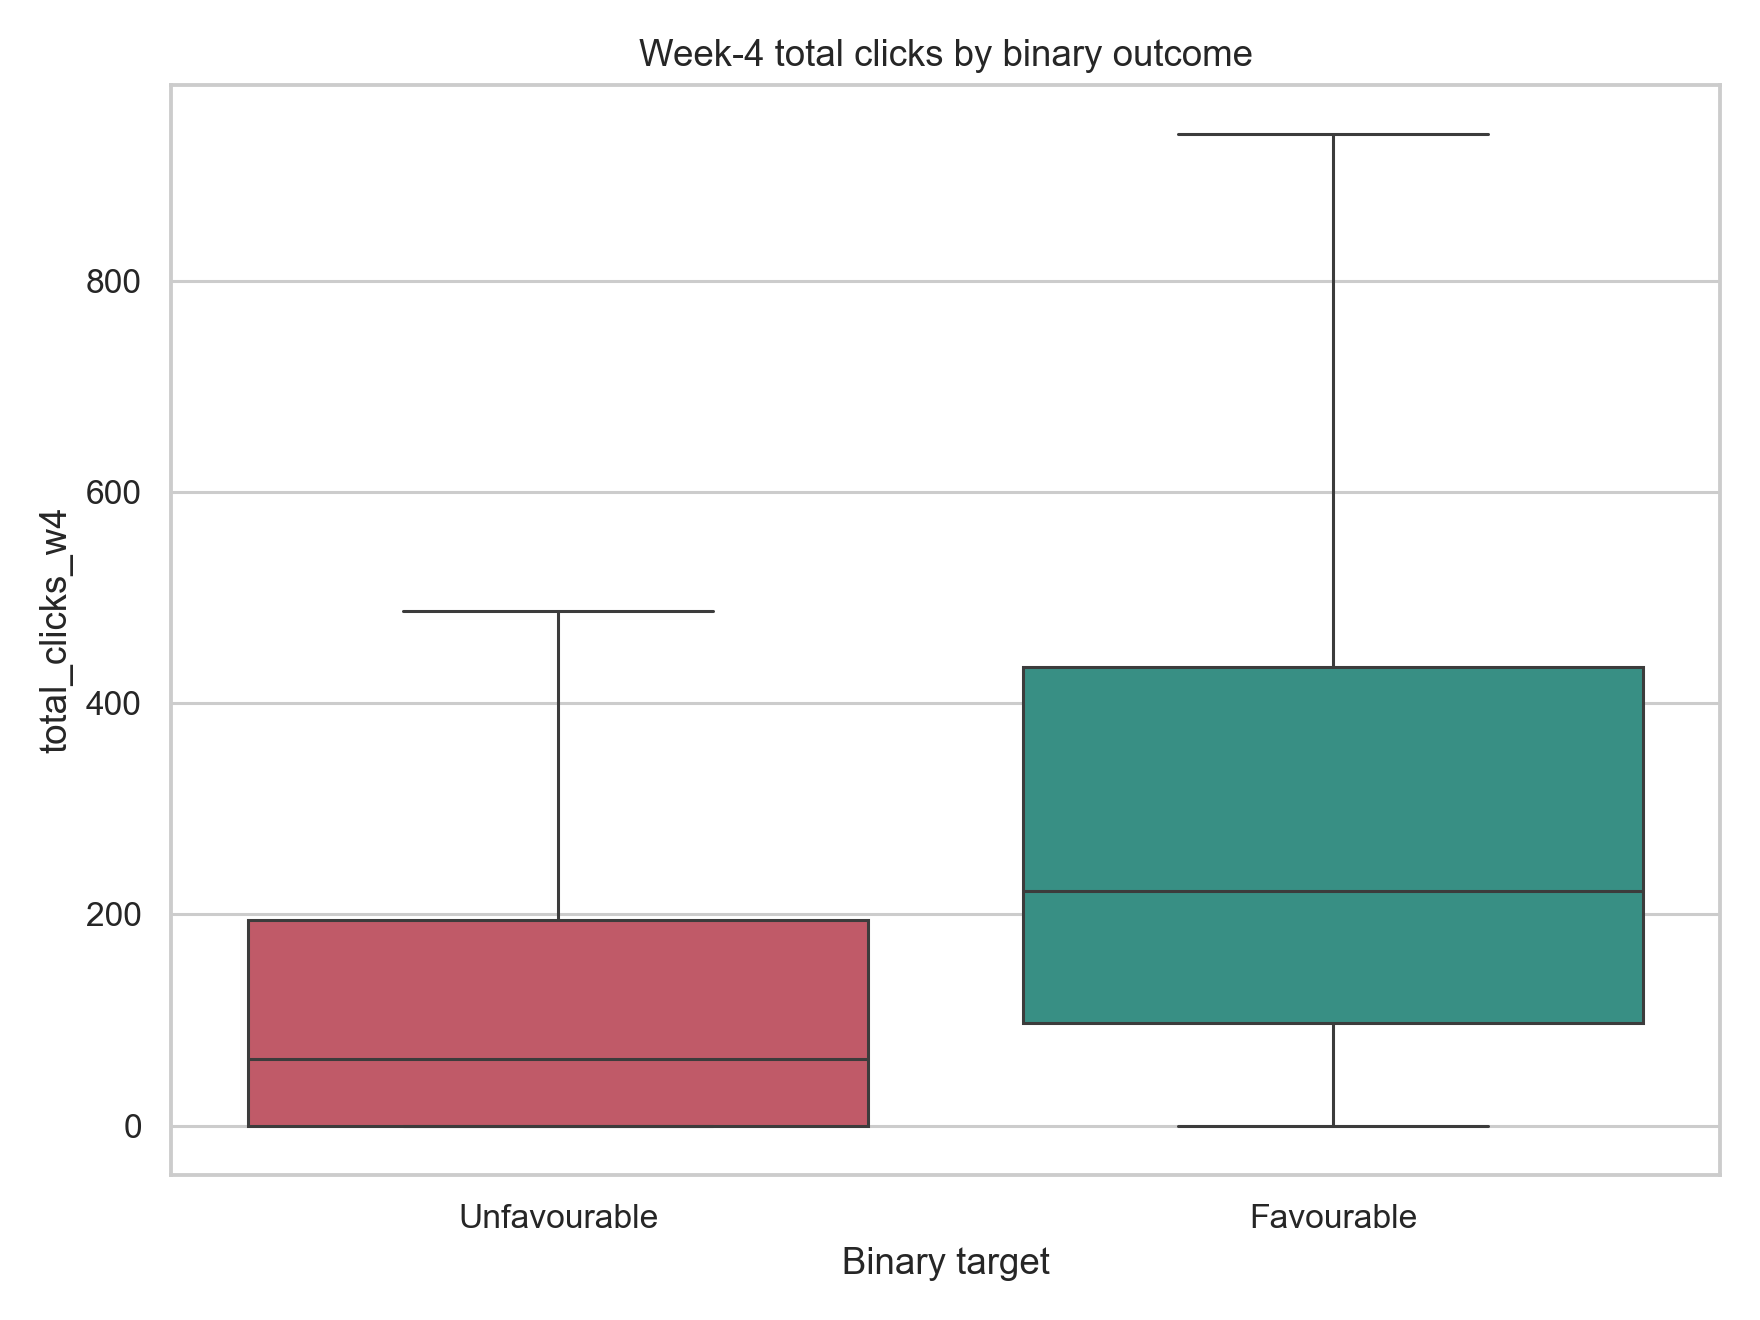

### Figure 3: Active days by outcome

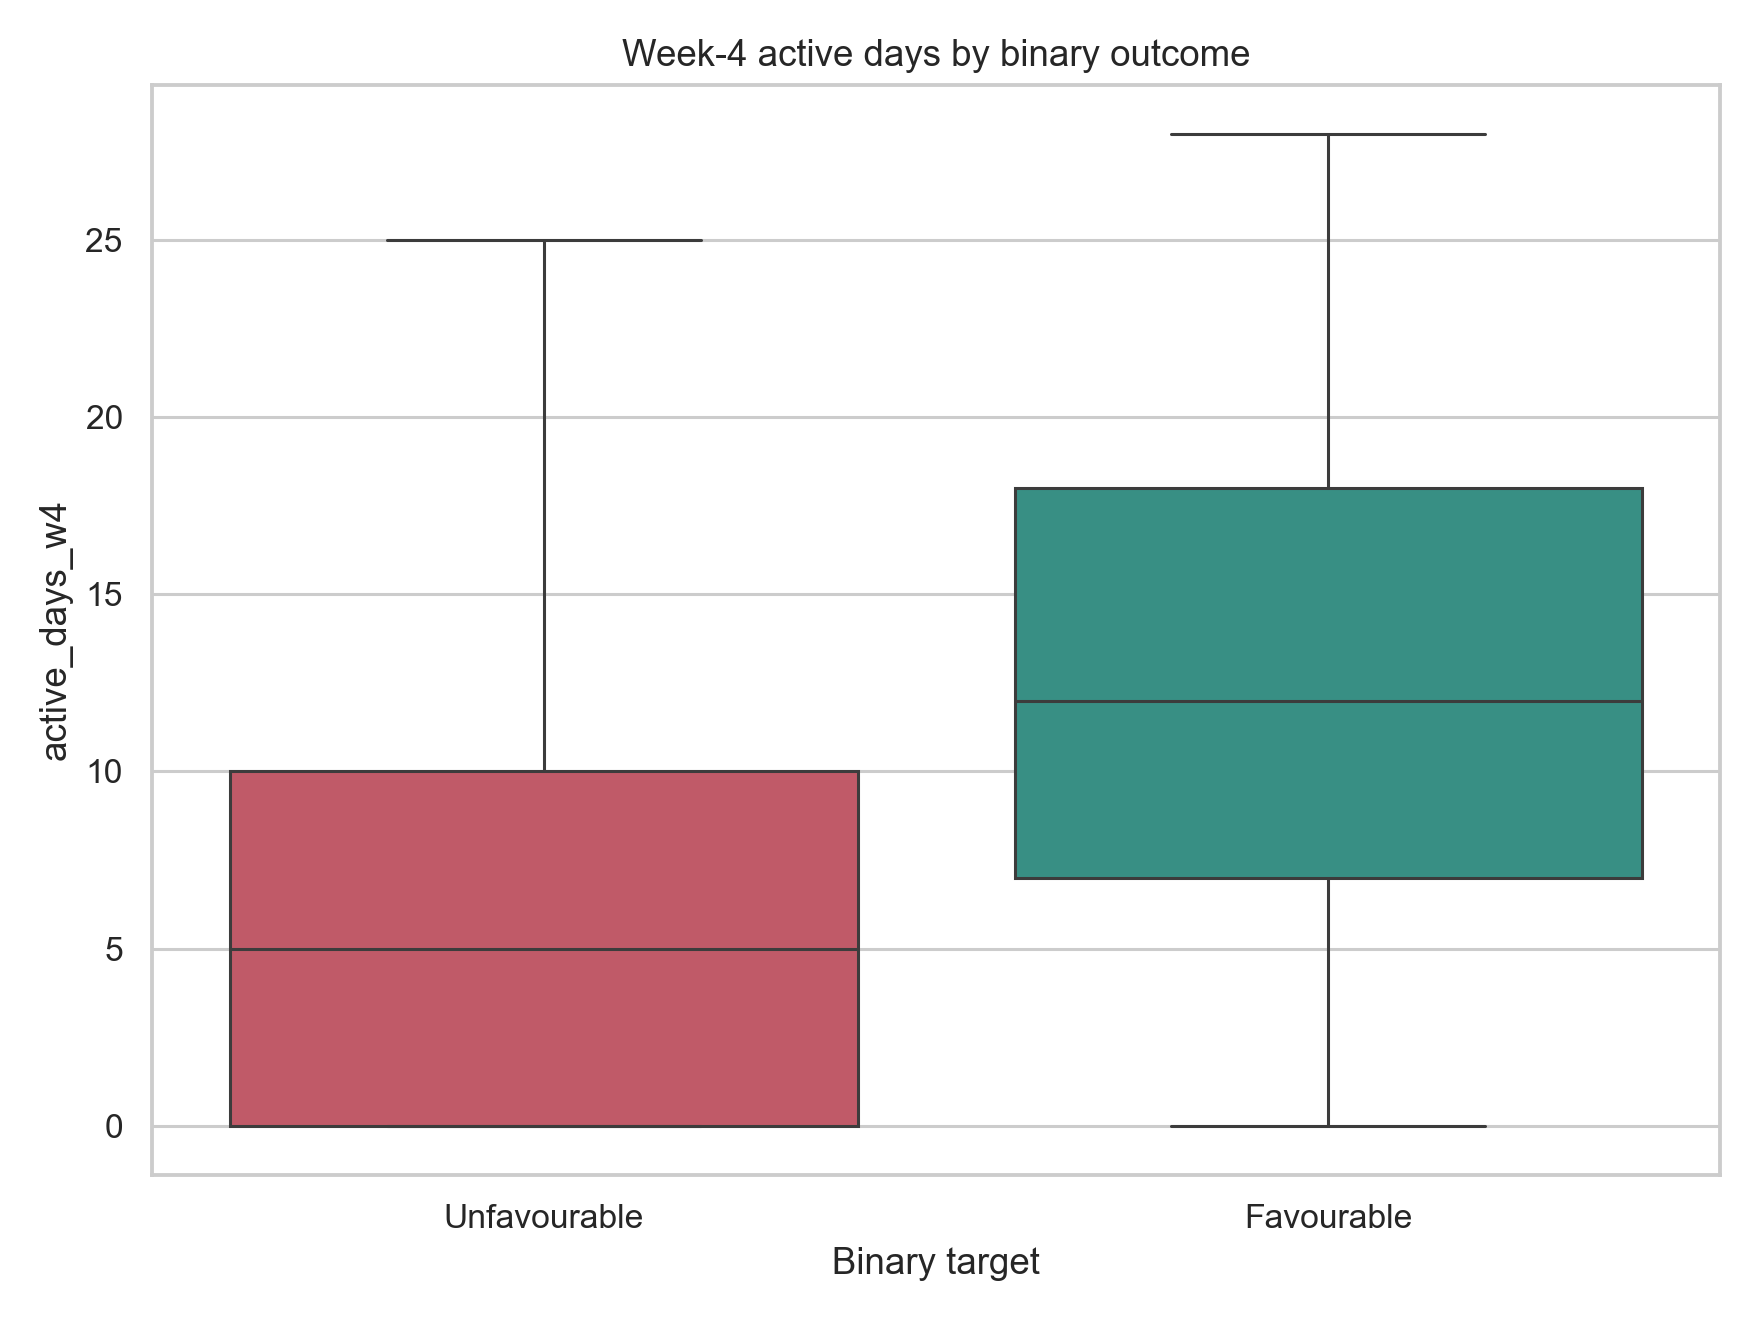

### Figure 4: Clicks per active day by outcome

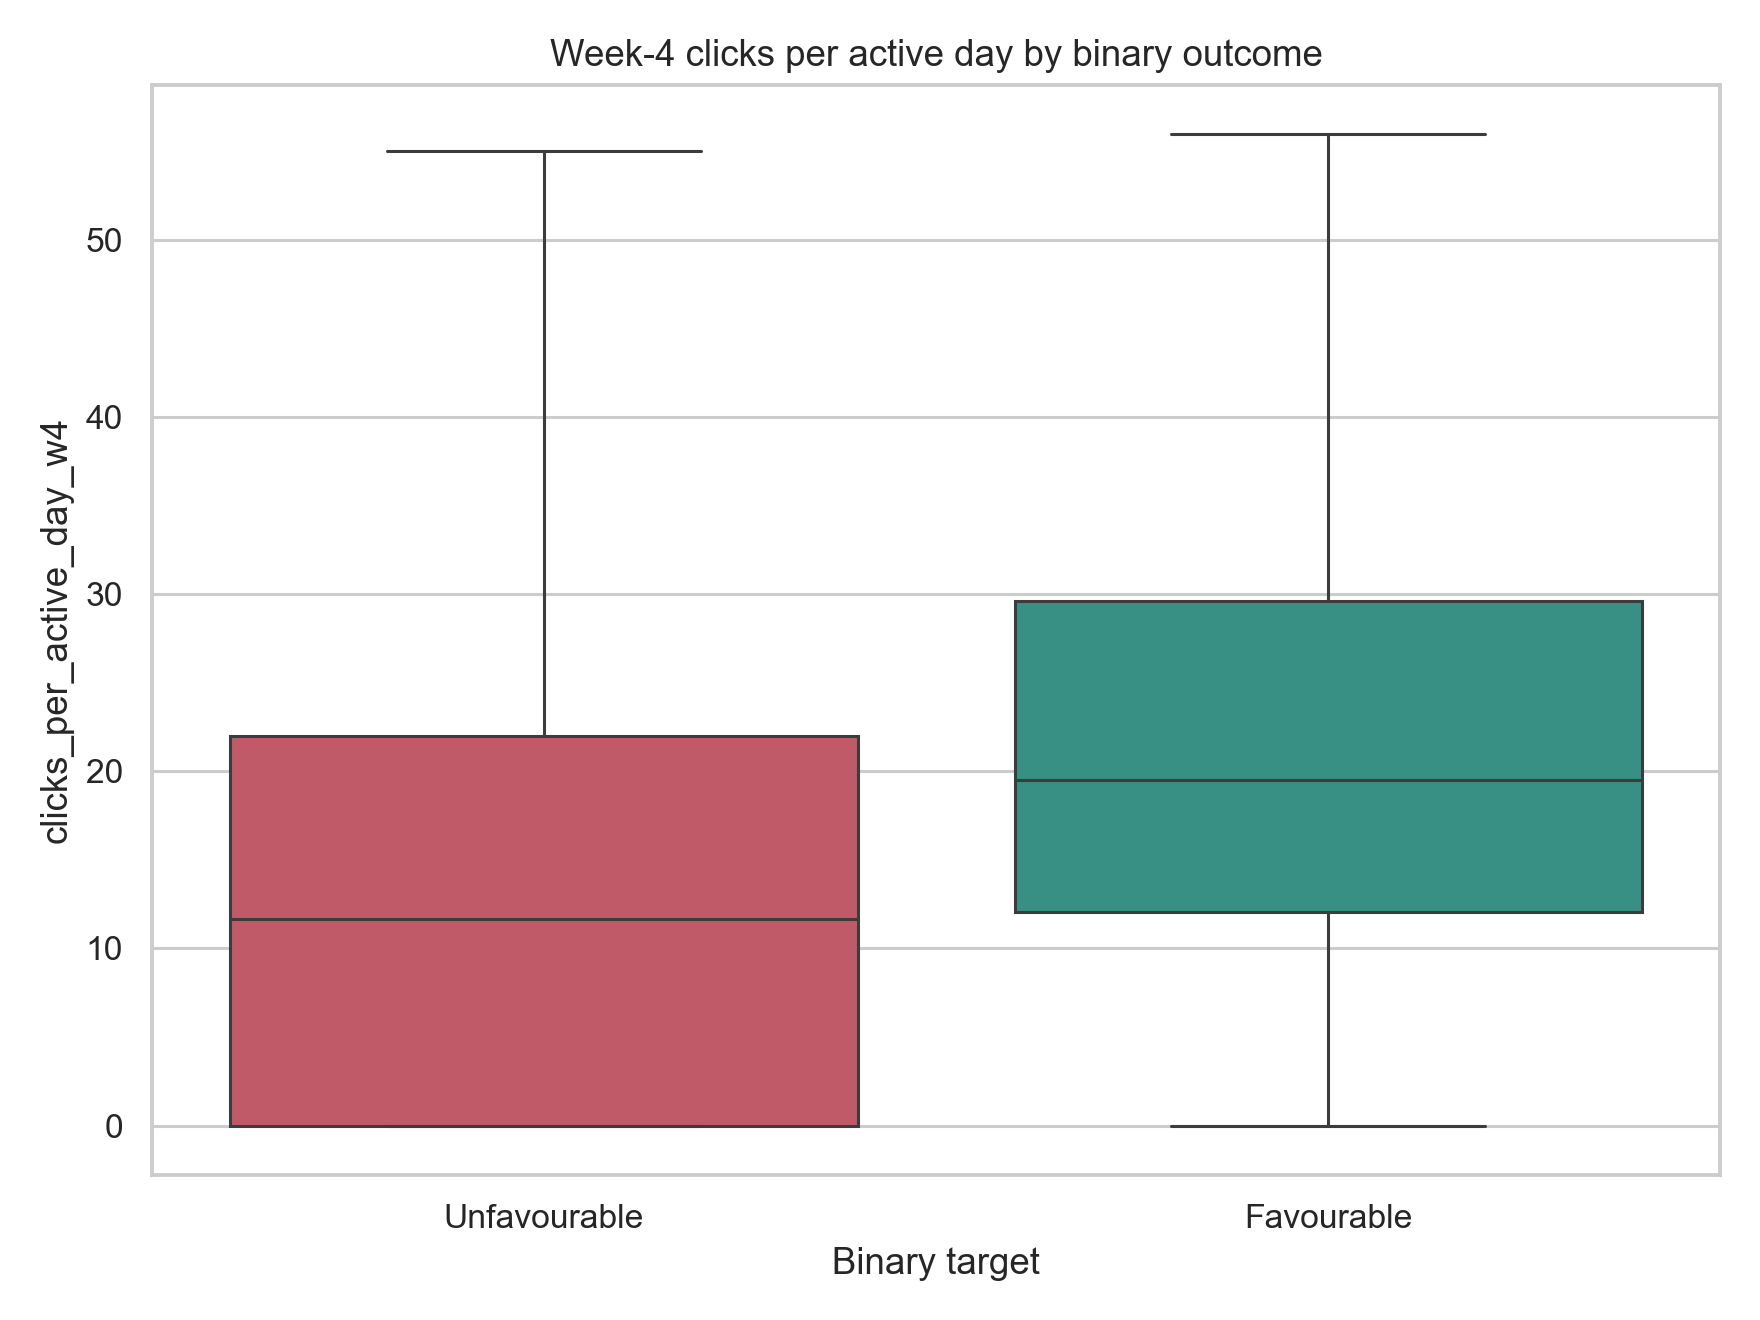

### Figure 5: Weighted early submissions by outcome

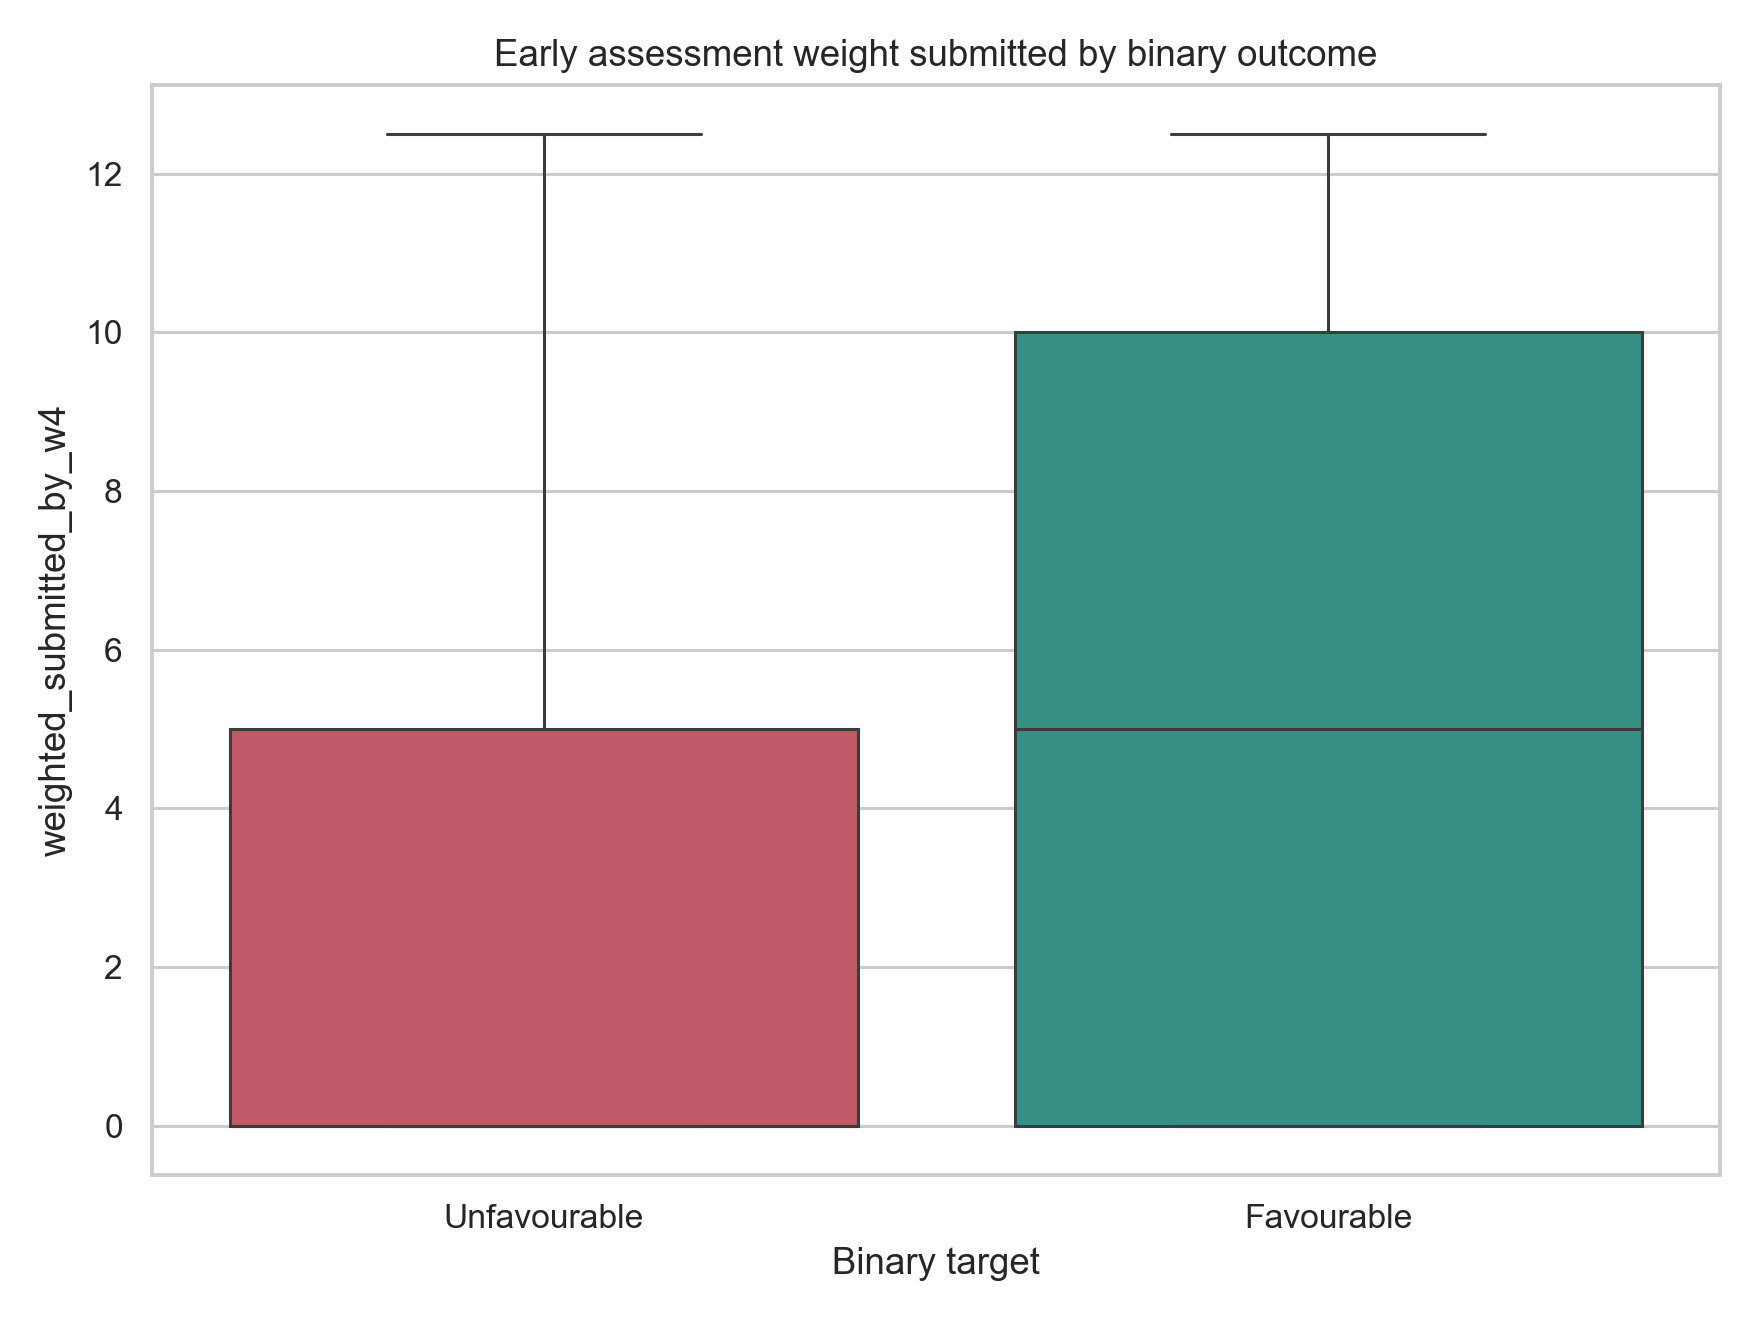

### Figure 6: Confusion matrices

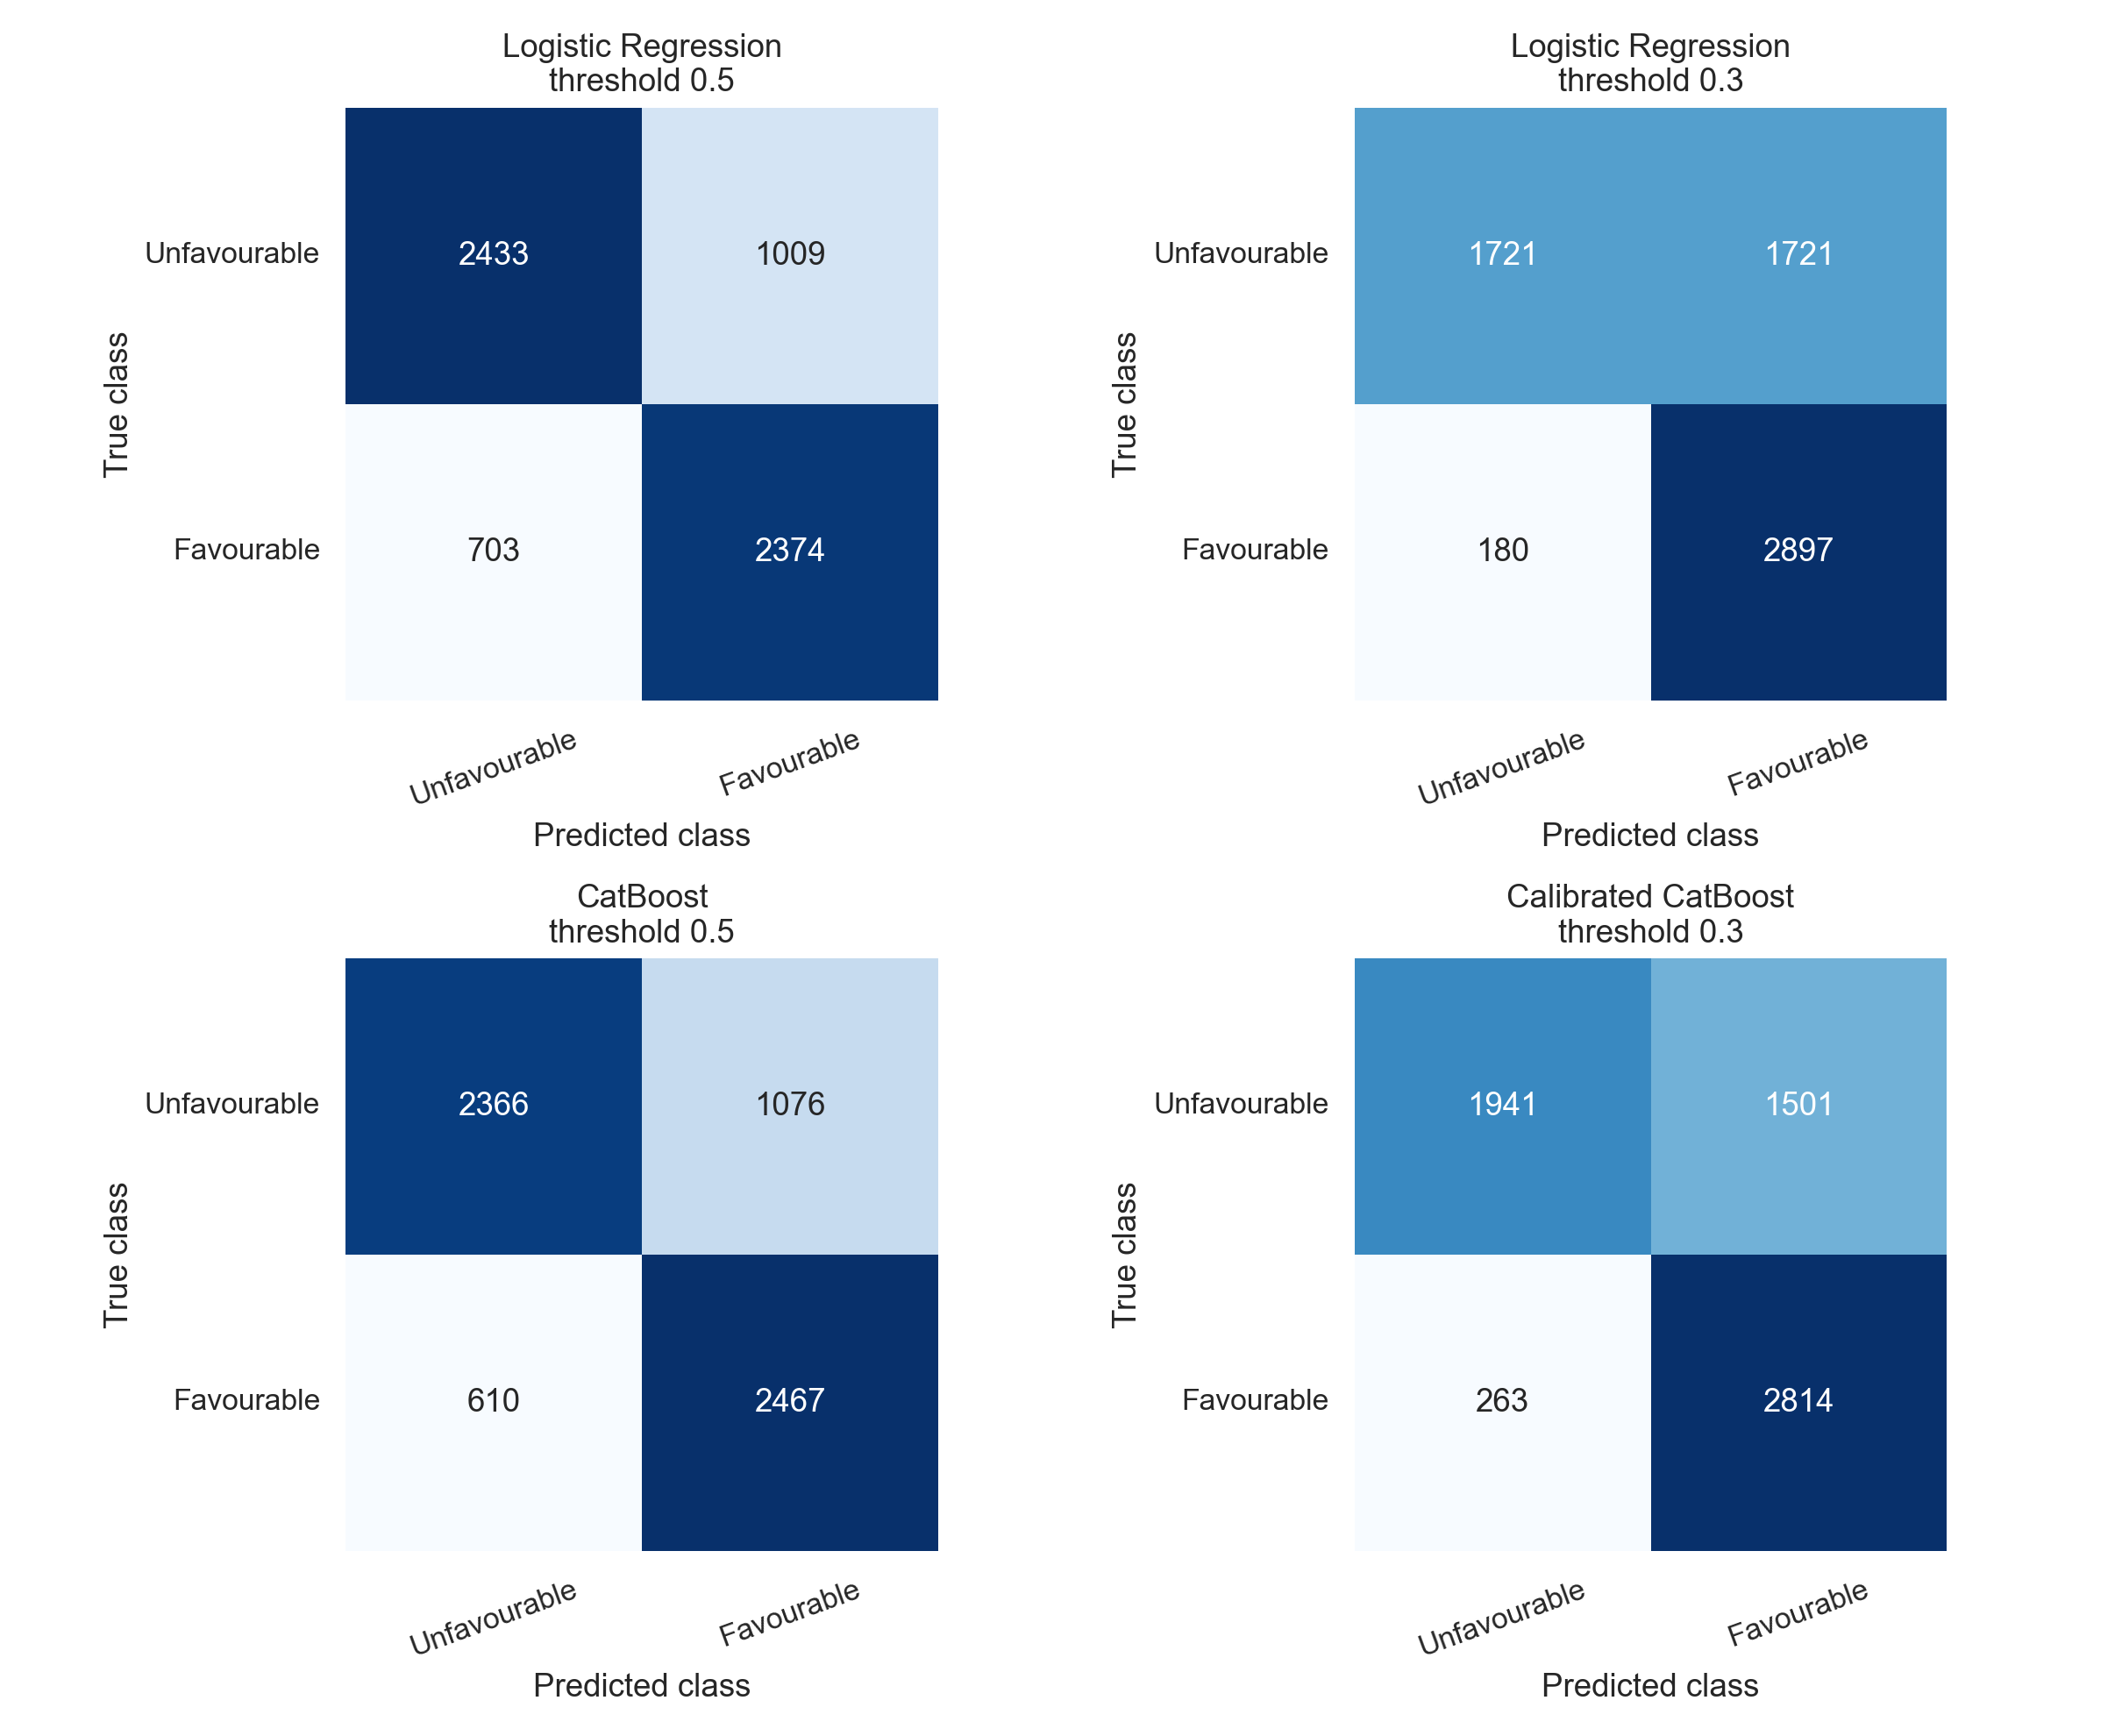

### Figure 7: ROC curves

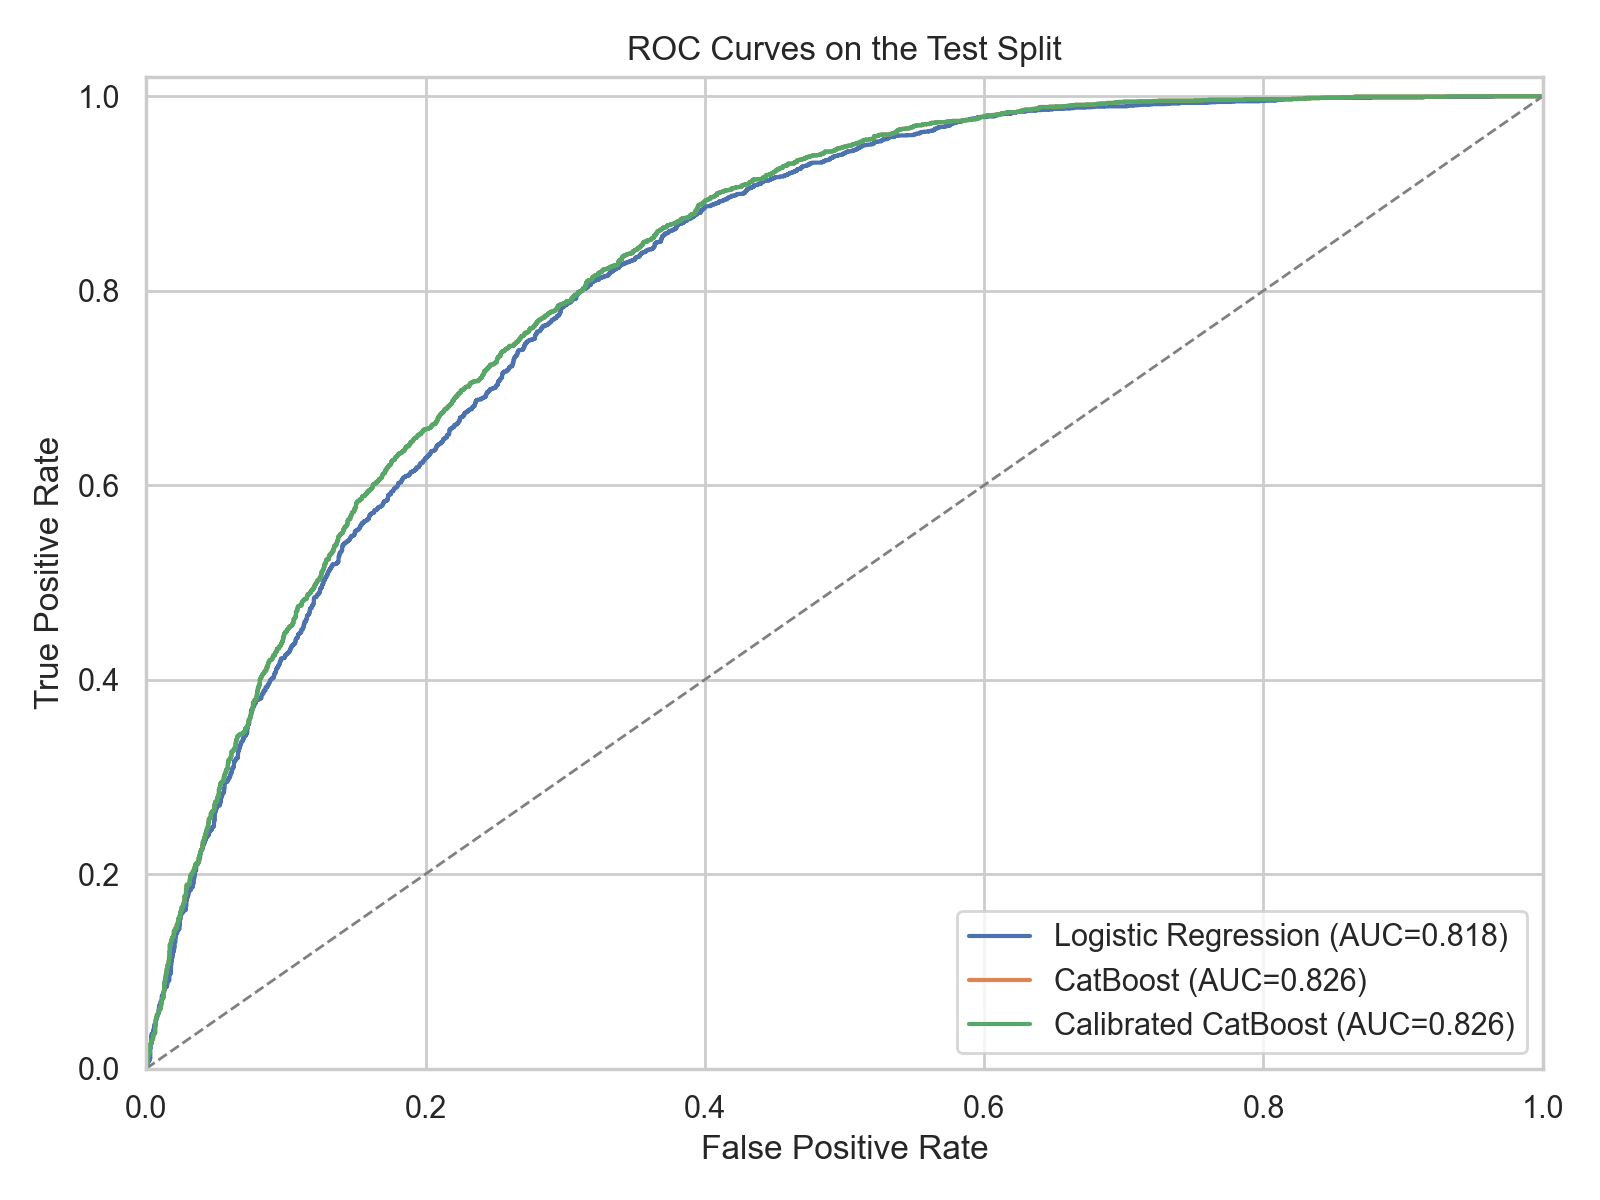

### Figure 8: Threshold sweep

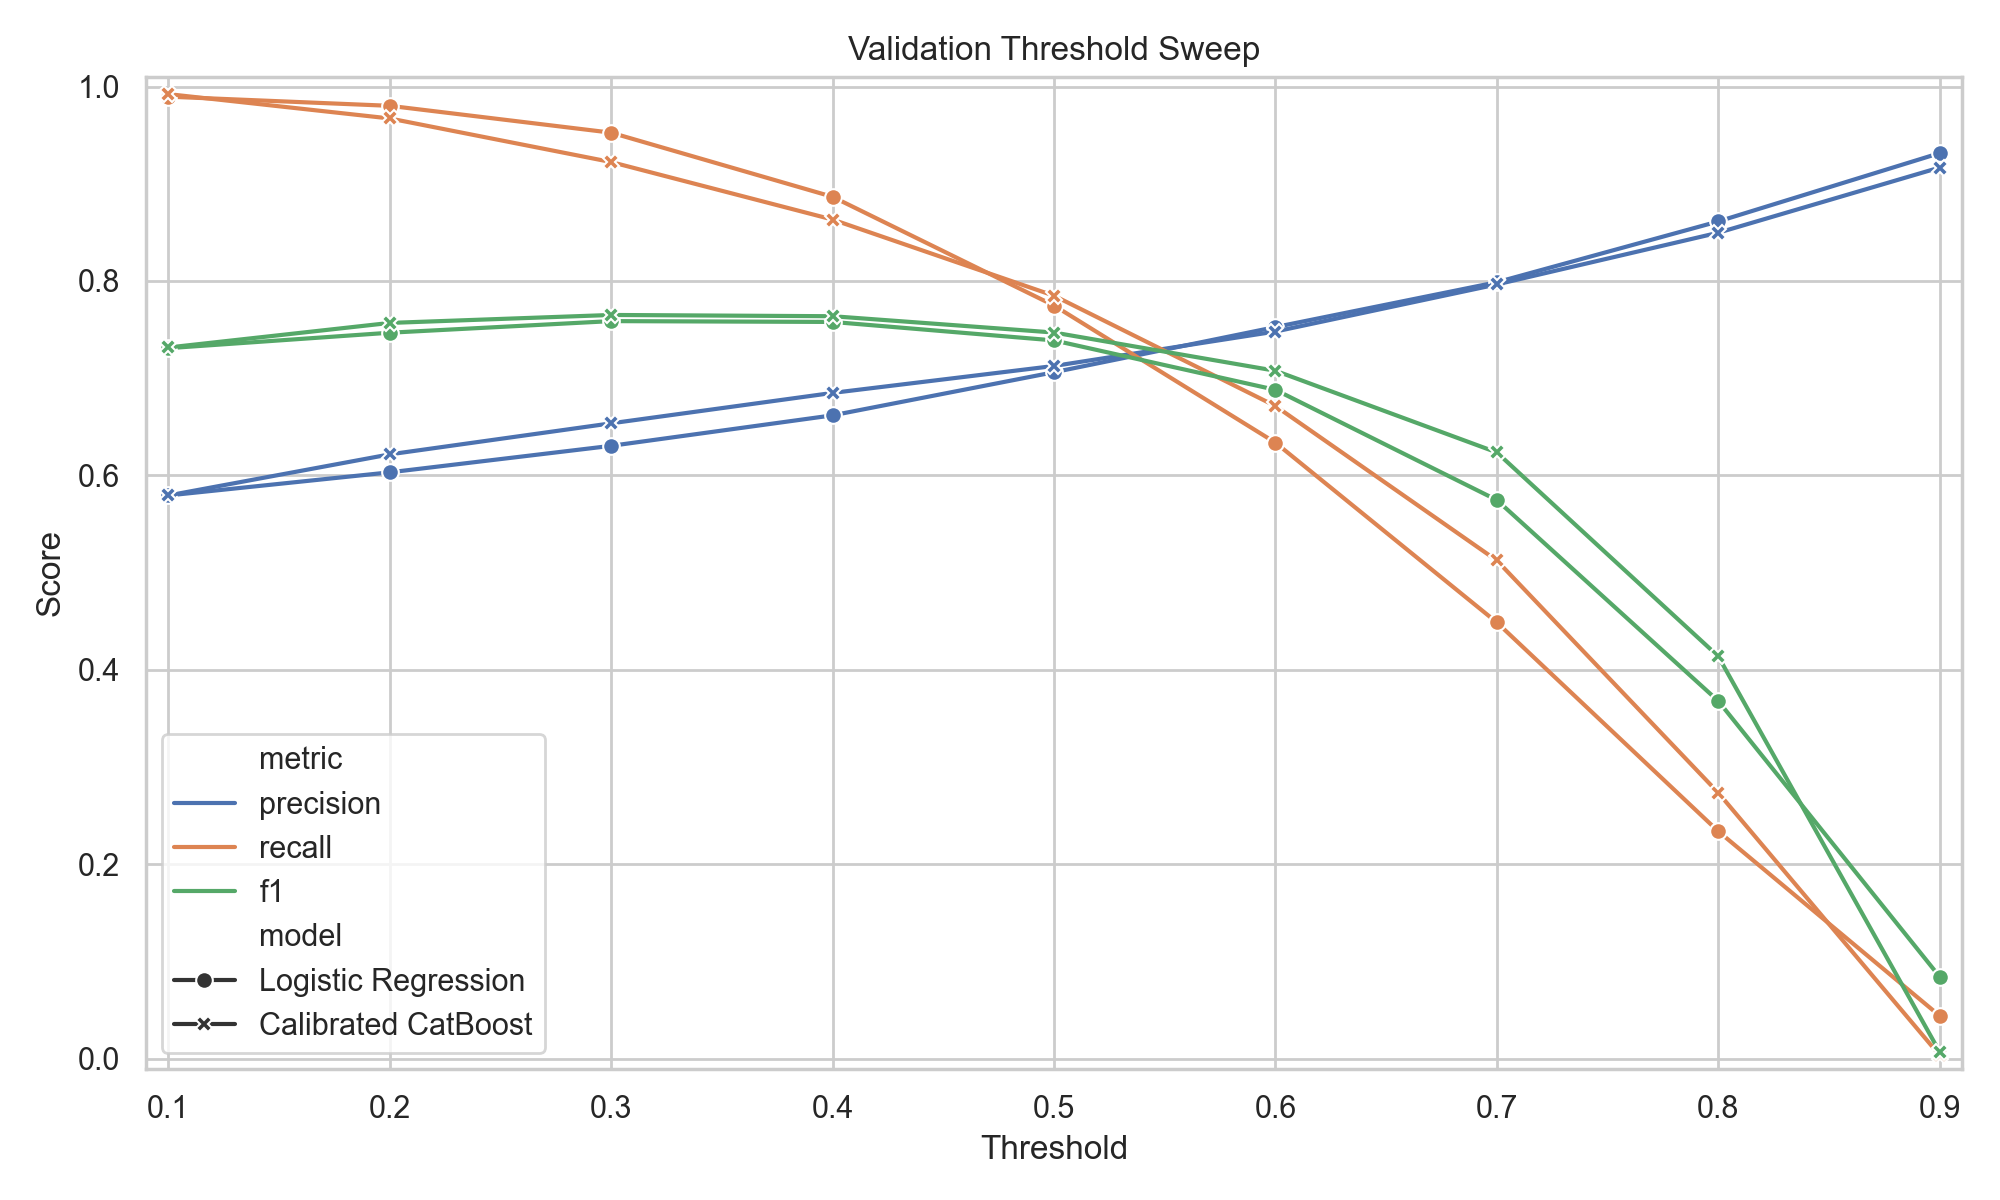

### Figure 9: Metric comparison

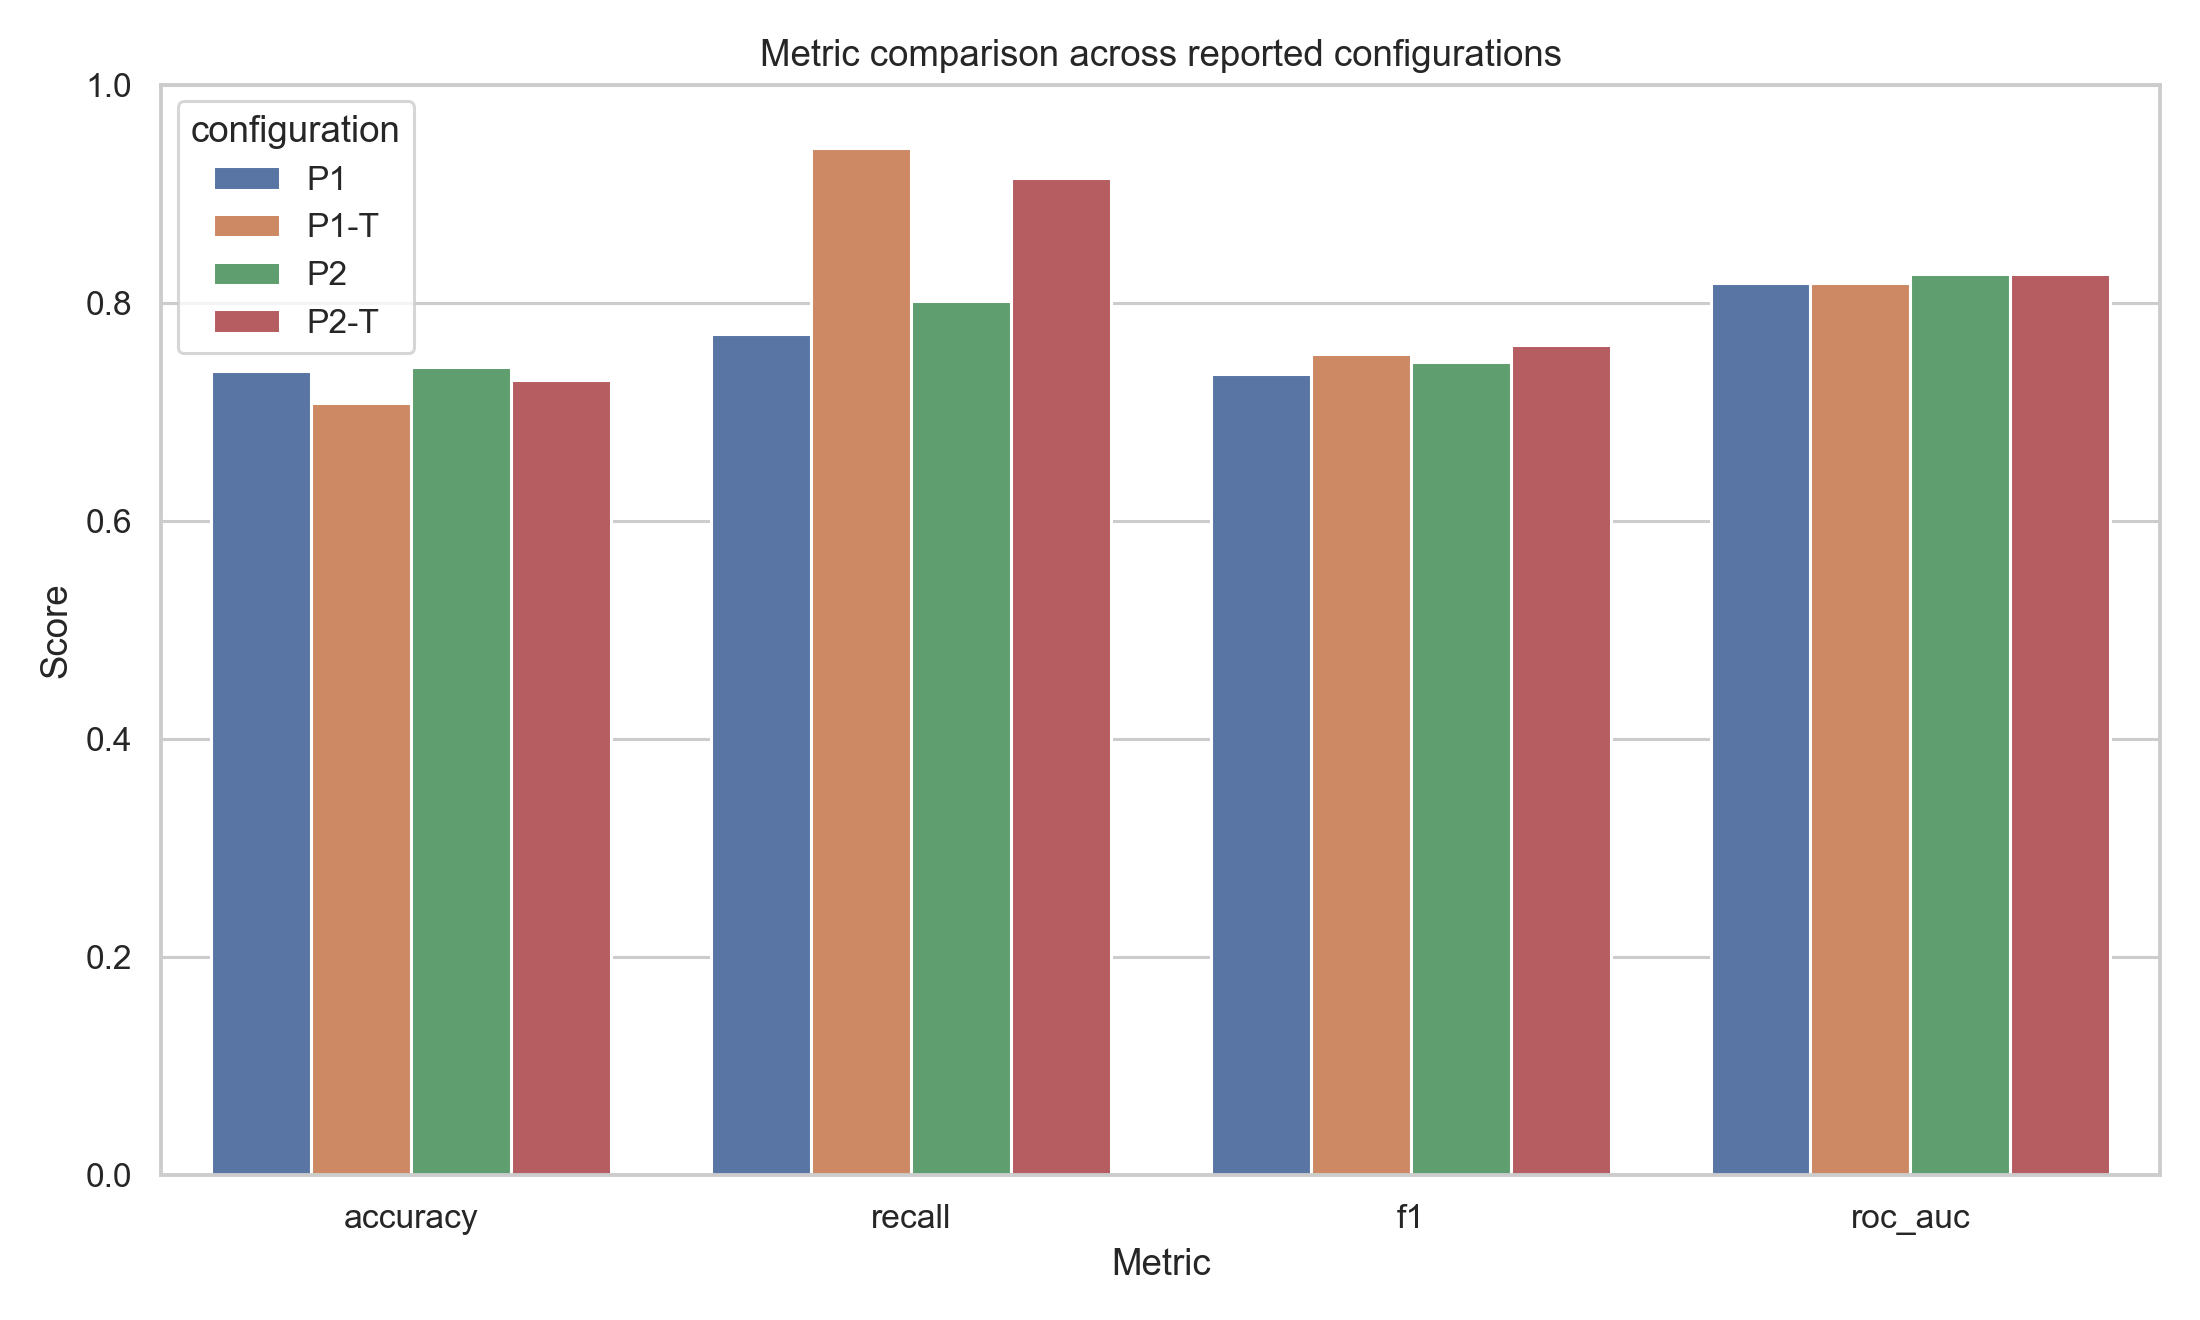

In [9]:
figure_titles = {
    "figure_1": "Methodology block diagram",
    "figure_2": "Total clicks by outcome",
    "figure_3": "Active days by outcome",
    "figure_4": "Clicks per active day by outcome",
    "figure_5": "Weighted early submissions by outcome",
    "figure_6": "Confusion matrices",
    "figure_7": "ROC curves",
    "figure_8": "Threshold sweep",
    "figure_9": "Metric comparison",
}

for figure_id, figure_path in figures.items():
    display(Markdown(f"### {figure_id.replace('_', ' ').title()}: {figure_titles.get(figure_id, figure_id)}"))
    display(Image(filename=str(figure_path), embed=True))


## 10. Literature Matrix

The literature matrix is kept in the notebook so the cited method choices are visible beside the runnable code.


In [10]:
display(results["literature_matrix"])


,section,report_section,pdf_path,title,reference_hint,venue,year,doi,selected_claim,metadata_title,metadata_author,title_found_in_excerpt,evidence_note,first_page_excerpt
0,Background and Problem Framing,Introduction / related work,"Background & Problem Framing (OULAD, Early Pre...",Early Prediction of At Risk Students Using Min...,"Hamsiah, Adiyati, and Subekti (2025)",Digitus: Journal of Computer Science Applications,2025,,Week-4 OULAD features combined with CatBoost a...,The Illomata International Journal of Management,Mohammad Sofyan,True,Verify final citation details against the PDF ...,Digitus : Journal of Computer Science Applicat...
1,Week-4 Clickstream Features,Feature engineering,Week 4 features\education-13-00017-v3.pdf,Predicting Student Performance Using Clickstre...,Liu et al. (2022),Education Sciences,2022,10.3390/educsci13010017,Activity-specific clickstream features carry s...,Predicting Student Performance Using Clickstre...,"Yutong Liu, Si Fan, Shuxiang Xu, Atul Sajjanha...",True,Verify final citation details against the PDF ...,"Citation: Liu, Y.; Fan, S.; Xu, S.; Sajjanhar,..."
2,Demographic and Enrollment Features,Feature engineering,Demographic & Enrollment Features\PIIS24058440...,Predictive modelling of student dropout risk: ...,Seo et al. (2024),Heliyon,2024,10.1016/j.heliyon.2024.e30960,Demographic and enrollment information improve...,Predictive modelling of student dropout risk: ...,Eui-Yeong Seo,True,Verify final citation details against the PDF ...,Heliyon 10 (2024) e30960 Available online 9 Ma...
3,Early Assessment Features,Feature engineering,Early Assessment Features\Early_Prediction_of_...,Early Prediction of Dropout and Final Exam Per...,Figueroa-Cañas et al. (2020),IEEE Revista Iberoamericana de Tecnologias del...,2020,10.1109/RITA.2020.2987727,Early formative assessment behavior can improv...,Early Prediction of Dropout and Final Exam Per...,,True,Verify final citation details against the PDF ...,86 IEEE REVISTA IBEROAMERICANA DE TECNOLOGIAS ...
4,Logistic Regression Baseline,Model 1 baseline,Logistic Regression as Taught Baseline\Predict...,Predicting student dropout: A machine learning...,Kemper et al. (2020),European Journal of Higher Education,2020,10.1080/21568235.2020.1718520,"Logistic regression is a credible, interpretab...",Predicting student dropout: A machine learning...,,True,Verify final citation details against the PDF ...,European Journal of Higher Education ISSN: 215...
5,CatBoost in Education,Model 2 self-learned method,CatBoost as Self-Learned Model (Education-Spec...,Student dropout prediction through machine lea...,Marcolino et al. (2025),Scientific Reports,2025,10.1038/s41598-025-93918-1,CatBoost performs strongly on higher-education...,,,True,Verify final citation details against the PDF ...,Student dropout prediction through machine lea...
6,CatBoost Technical Justification,Model 2 self-learned method,CatBoost Technical Justification (FallbackAlgo...,CatBoost for big data: an interdisciplinary re...,Hancock and Khoshgoftaar (2020),Journal of Big Data,2020,10.1186/s40537-020-00369-8,CatBoost is especially suitable for heterogene...,CatBoost for big data: an interdisciplinary re...,John T. Hancock,True,Verify final citation details against the PDF ...,CatBoost for big data: an interdisciplinary re...
7,Class Weighting and Imbalanced Learning,Model 2 self-learned method,Class Weighting & Imbalanced Learning\applsci-...,The Machine Learning-Based Dropout Early Warni...,Lee et al. (2019),Applied Sciences,2019,10.3390/app9153093,Imbalance-aware training should be evaluated w...,The Machine Learning-Based Dropout Early Warni...,Sunbok Lee and Jae Young Chung,True,Verify final citation details against the PDF ...,applied sciences Article The Machine Learning-...
8,Probability Calibration,Evaluation and thresholding,Probability Calibration\1706.04599v2.pdf,On Calibration of Modern Neural Networks,Guo et al. (2017),Proceedings of ICML,2017,,Raw classifier probabilities are oft

## 11. Run Summary

This final section records the main modelling choices and caveats for checking before submission.


In [11]:
calibration_delta = (
    results["calibrated_catboost_validation_log_loss"]
    - results["raw_catboost_validation_log_loss"]
)

summary = pd.DataFrame(
    [
        {"Check": "Week-4 cutoff", "Value": "Only days 0-27 are used in engineered features"},
        {"Check": "Leakage exclusions", "Value": "No post-week-4 clicks, no date_unregistration, no assessment score in model features"},
        {"Check": "Logistic validation log loss", "Value": f"{results['logistic_validation_log_loss']:.6f}"},
        {"Check": "Raw CatBoost validation log loss", "Value": f"{results['raw_catboost_validation_log_loss']:.6f}"},
        {"Check": "Calibrated CatBoost validation log loss", "Value": f"{results['calibrated_catboost_validation_log_loss']:.6f}"},
        {"Check": "Calibration delta", "Value": f"{calibration_delta:.6f}"},
        {"Check": "Important caveat", "Value": "This OULAD copy has no recommended field in vle.csv, so recommended-resource features are zero-valued placeholders."},
    ]
)

display(summary)


,Check,Value
0,Week-4 cutoff,Only days 0-27 are used in engineered features
1,Leakage exclusions,"No post-week-4 clicks, no date_unregistration,..."
2,Logistic validation log loss,0.495630
3,Raw CatBoost validation log loss,0.484638
4,Calibrated CatBoost validation log loss,0.492080
5,Calibration delta,0.007442
6,Important caveat,This OULAD copy has no recommended field in vl...
